Course: Introduction to Machine Learning
Project Title: Target Group Identification on X (Twitter)
Topic: Statistical Analysis and Classification of Israeli Users

Submitted by:
Matan Moridan 213445471
Ofir Ovadia 32415098


In [ ]:
!pip install -q pandas matplotlib seaborn scikit-learn xgboost openpyxl

Imports and Data Loading: Setting up libraries and loading the CSV dataset from the 'Data' directory.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

file_path = 'Data/final_israeli_users.xlsx'
df = pd.read_excel(file_path) 
df

,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage
0,amit_segal,False,22500,46.0,834700.0,פרשן פוליטי | חדשות 12 וידיעות אחרונות | אבא ש...,jerusalem israel,joined february 2010,Israeli,1
1,DudyBornovski,False,828,337.0,10300.0,who’s your daddy,tel-aviv israel,joined may 2010,Israeli,2
2,RamiRamii20,False,0,11.0,161.0,שאל תדע,nazareth,joined january 2022,Israeli,1
3,irish4israel,True,24800,NaN,NaN,this acc is now closed . follow ireland’s new ...,ireland,joined december 2010,Israeli,3
4,FleurEast,False,22500,4727.0,222100.0,singing dancing and laughing my way through li...,NaN,joined september 2010,Israeli,3
...,...,...,...,...,...,...,...,...,...,...
6960,itaylanda12,False,1126,881.0,123.0,NaN,israel,joined april 2023,Israeli,2
6961,DanShadur,False,66,356.0,158.0,documentary filmmaker producer and podcast host,israel,joined november 2018,Israeli,2
6962,SorinaMatei,False,6437,5961.0,5976.0,anchor news reporter blogger - investigative j...,bucharest romania,joined march 2009,Israeli,3
6963,TonyAbuAJ,False,5590,2290.0,423.0,לְעֵת תָּכִין מַטְבֵּחַ מִצָּר הַמְנַבֵּחַ,NaN,joined august 2019,Israeli,1


Data Preprocessing: Cleaning the 'join_date' string and converting it into a standard datetime object.

In [6]:


df['join_date_parsed'] = df['join_date'].str.replace('joined ', '')
df['join_date_parsed'] = pd.to_datetime(df['join_date_parsed'], format='%B %Y', errors='coerce')

# Display the cleaned dates to ensure successful conversion
df[['join_date', 'join_date_parsed']]

,join_date,join_date_parsed
0,joined february 2010,2010-02-01
1,joined may 2010,2010-05-01
2,joined january 2022,2022-01-01
3,joined december 2010,2010-12-01
4,joined september 2010,2010-09-01
...,...,...
6960,joined april 2023,2023-04-01
6961,joined november 2018,2018-11-01
6962,joined march 2009,2009-03-01
6963,joined august 2019,2019-08-01


Statistical Metrics & Export: Calculating min, max, mean, median, and std for key metrics, and saving the results to 'author_statistics.csv'.

In [7]:
total_users = df['username'].nunique()

stats_data = {
    'Metric': [
        'Total unique users',
        'Min posts', 'Max posts', 'Average posts', 'Median posts', 'Std posts',
        'Min followers', 'Max followers', 'Average followers', 'Median followers', 'Std followers',
        'Min following', 'Max following', 'Average following', 'Median following', 'Std following',
        'Oldest join date', 'Newest join date'
    ],
    'Value': [
        total_users,
        df['posts'].min(), df['posts'].max(), round(df['posts'].mean(), 2), df['posts'].median(), round(df['posts'].std(), 2),
        df['followers'].min(), df['followers'].max(), round(df['followers'].mean(), 2), df['followers'].median(), round(df['followers'].std(), 2),
        df['following'].min(), df['following'].max(), round(df['following'].mean(), 2), df['following'].median(), round(df['following'].std(), 2),
        df['join_date_parsed'].min().strftime('%Y-%m'), df['join_date_parsed'].max().strftime('%Y-%m')
    ]
}

stats_df = pd.DataFrame(stats_data)

# Export the statistics to a CSV file
stats_df.to_csv('author_statistics.csv', index=False)

# Display the summary table
stats_df

,Metric,Value
0,Total unique users,6965
1,Min posts,0
2,Max posts,1300000
3,Average posts,20947.22
4,Median posts,5347.0
5,Std posts,51592.24
6,Min followers,0.0
7,Max followers,65500000.0
8,Average followers,116158.16
9,Median followers,2839.0


Visualization: Creating and saving histograms for followers, following, and posts.

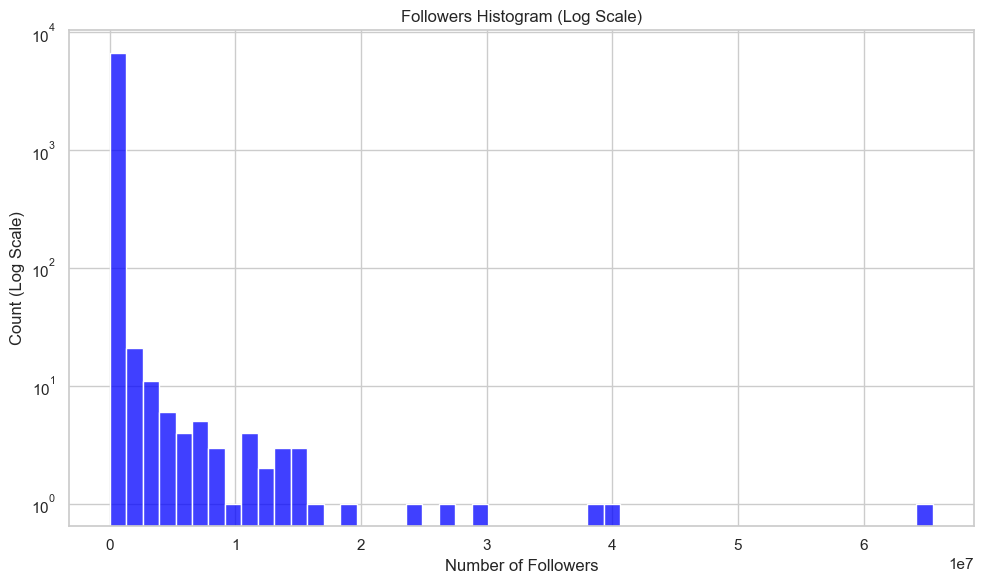

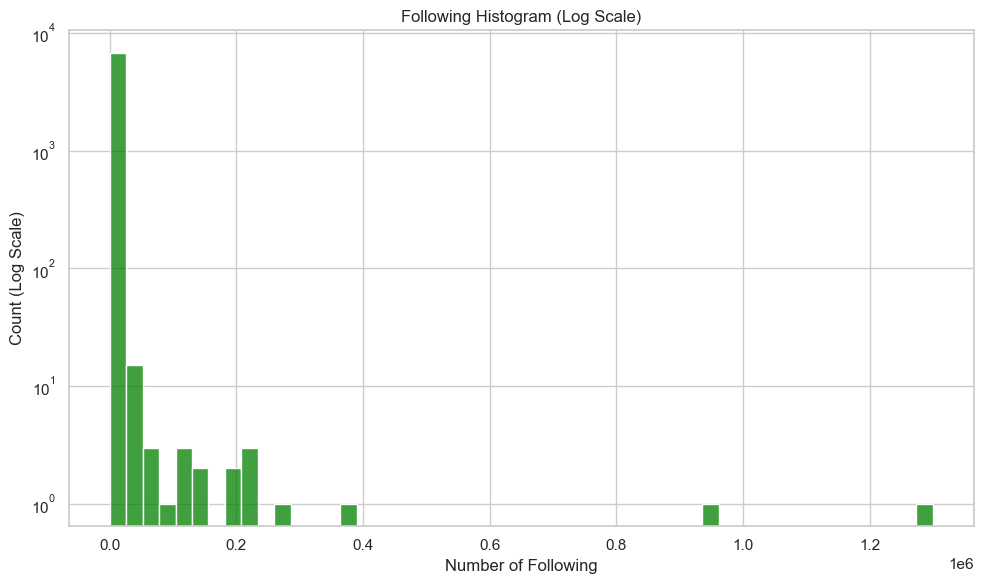

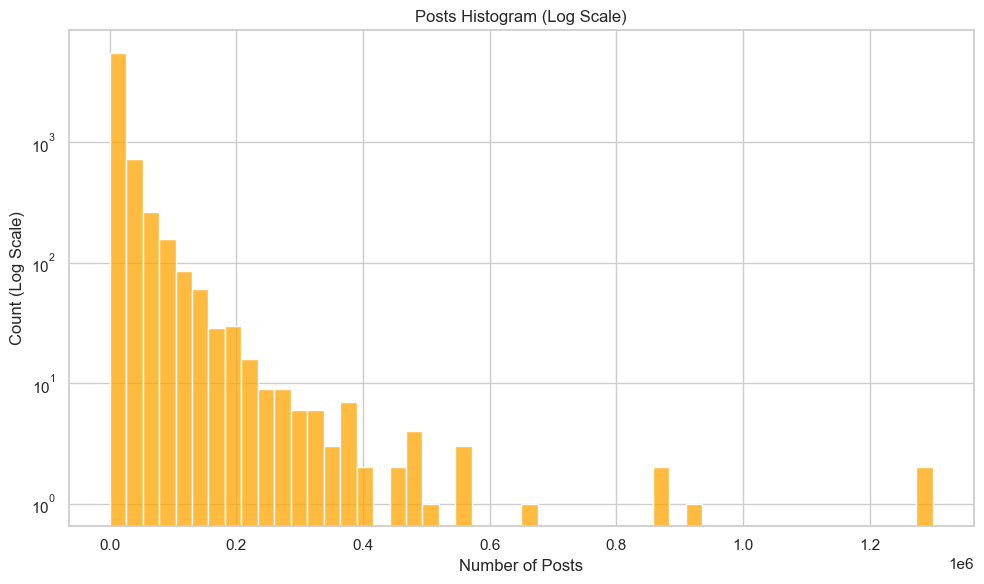

In [8]:
sns.set_theme(style="whitegrid")
# 1. Followers Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['followers'], bins=50, color='blue')
plt.yscale('log')
plt.title('Followers Histogram (Log Scale)')
plt.xlabel('Number of Followers')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
plt.savefig('followers_histogram.png')
plt.show()

# 2. Following Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['following'], bins=50, color='green')
plt.yscale('log')
plt.title('Following Histogram (Log Scale)')
plt.xlabel('Number of Following')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
plt.savefig('following_histogram.png')
plt.show()

# 3. Posts Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['posts'], bins=50, color='orange')
plt.yscale('log')
plt.title('Posts Histogram (Log Scale)')
plt.xlabel('Number of Posts')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
plt.savefig('posts_histogram.png')
plt.show()

**Data Exploration Insights:**
The dataset exhibits a "long-tail" distribution typical of social media, with a few extreme outliers heavily skewing the averages upwards compared to the medians. The varied account creation dates provide a diverse timeline for future feature engineering.

## Random Sampling for Manual Annotation

A random subset of users is selected from the dataset in order to create the initial manually labeled dataset for the annotation process.

In [9]:
# Randomly select 100 users from the dataset
sample_df = df.sample(n=100, random_state=42)

# Display the first rows of the sampled dataset
sample_df

,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage,join_date_parsed
1335,Roy_Iddan,False,118400,5619.0,79100.0,tv writer uke player + high functioning sociop...,israel,joined may 2009,Israeli,1,2009-05-01
5679,RayneNGrace,False,652500,5459.0,3827.0,imperfect loved by a perfect god! \nmarried to...,blessed usa,joined april 2011,Israeli,3,2011-04-01
5962,shirellaloom,False,23000,680.0,10300.0,כתבת יו''ש | עכשיו 14 | אמא לשני קטנים מתוקים ...,ישראל,joined february 2016,Israeli,1,2016-02-01
37,raananshaked,False,6425,717.0,53300.0,כעס. למרות כל מה שג'וי אומרת כדי לנסות להרגיע ...,NaN,joined march 2009,Israeli,1,2009-03-01
5939,IsraelMOH,False,3506,112.0,20800.0,הטוויטר הרשמי של משרד הבריאות | הצטרפו לערוץ ה...,israel,joined december 2013,Israeli,1,2013-12-01
...,...,...,...,...,...,...,...,...,...,...,...
4258,Lauren_Provost,False,14000,2932.0,10500.0,journalisme numérique dans un quotidien libre....,paris,joined march 2010,Israeli,3,2010-03-01
1600,Yesh_Din,False,845,279.0,12200.0,yesh din is an israeli human rights ngo workin...,west bank/tel aviv,joined september 2022,Israeli,2,2022-09-01
4728,ElfeVan,False,19200,663.0,273.0,NaN,niederlande,joined july 2020,Israeli,2,2020-07-01
742,asafzamir,False,1544,481.0,35800.0,וממלא מקומו,NaN,joined march 2009,Israeli,1,2009-03-01


## Annotation Dataset Preparation

Preparing the sampled dataset for the manual annotation process by selecting relevant columns and creating empty annotation fields.

In [10]:
# Keep only relevant columns for annotation
annotation_df = sample_df[['username', 'bio', 'location']].copy()

# Create empty annotation columns
annotation_df['target_population'] = ""
annotation_df['locals_vs_diaspora'] = ""
annotation_df['person_vs_organization'] = ""
annotation_df['comments'] = ""

# Display the annotation dataset
annotation_df

,username,bio,location,target_population,locals_vs_diaspora,person_vs_organization,comments
1335,Roy_Iddan,tv writer uke player + high functioning sociop...,israel,,,,
5679,RayneNGrace,imperfect loved by a perfect god! \nmarried to...,blessed usa,,,,
5962,shirellaloom,כתבת יו''ש | עכשיו 14 | אמא לשני קטנים מתוקים ...,ישראל,,,,
37,raananshaked,כעס. למרות כל מה שג'וי אומרת כדי לנסות להרגיע ...,NaN,,,,
5939,IsraelMOH,הטוויטר הרשמי של משרד הבריאות | הצטרפו לערוץ ה...,israel,,,,
...,...,...,...,...,...,...,...
4258,Lauren_Provost,journalisme numérique dans un quotidien libre....,paris,,,,
1600,Yesh_Din,yesh din is an israeli human rights ngo workin...,west bank/tel aviv,,,,
4728,ElfeVan,NaN,niederlande,,,,
742,asafzamir,וממלא מקומו,NaN,,,,


In [ ]:

ofir_path = "Classification/iteration_1_annotation_ofir.csv"
if not os.path.exists(ofir_path):
    annotation_df.to_csv(ofir_path, index=False, encoding='utf-8-sig')
    print(f"Created: {ofir_path}")
else:
    print(f"File already exists, skipped: {ofir_path}")

matan_path = "Classification/iteration_1_annotation_matan.csv"
if not os.path.exists(matan_path):
    annotation_df.to_csv(matan_path, index=False, encoding='utf-8-sig')
    print(f"Created: {matan_path}")
else:
    print(f"File already exists, skipped: {matan_path}")

File already exists, skipped: Classification/iteration_1_annotation_ofir.csv
File already exists, skipped: Classification/iteration_1_annotation_matan.csv


Inter-Rater Agreement & Conflict Extraction
In this step, we merge the independent annotations performed by both team members to identify discrepancies. 
The code compares the three classification labels (`target_population`, `locals_vs_diaspora`, `person_vs_organization`) and extracts only the rows where the annotators disagreed. 
These conflicting records are exported to a dedicated file (`conflicts_to_resolve.csv`) for a joint manual review, allowing us to discuss and reach a final consensus (Ground Truth) before calculating the final agreement metrics.

In [ ]:
df_matan = pd.read_csv('Classification/iteration_1_annotation_matan.csv')
df_ofir = pd.read_csv('Classification/iteration_1_annotation_ofir.csv')

# Merge the dataframes based on the username column
df_merged = pd.merge(df_matan, df_ofir, on='username', suffixes=('_matan', '_ofir'))

# Define the columns that need to be compared
label_columns = ['target_population', 'locals_vs_diaspora', 'person_vs_organization']

# Create a condition (mask) to find rows where at least one label does not match
conflict_mask = (
    (df_merged['target_population_matan'] != df_merged['target_population_ofir']) |
    (df_merged['locals_vs_diaspora_matan'] != df_merged['locals_vs_diaspora_ofir']) |
    (df_merged['person_vs_organization_matan'] != df_merged['person_vs_organization_ofir'])
)

# Extract only the users that have conflicting annotations
df_conflicts = df_merged[conflict_mask].copy()

# Create empty columns for the final decision that will be made during the discussion
for col in label_columns:
    df_conflicts[f'{col}_final'] = ''

# Reorder columns for a convenient side-by-side comparison
columns_to_export = ['username']
for col in label_columns:
    columns_to_export.extend([f'{col}_matan', f'{col}_ofir', f'{col}_final'])
columns_to_export.extend(['comments_matan', 'comments_ofir'])

# Define the output path
output_path = 'Classification/conflicts_to_resolve.csv'

# Check if the file already exists
if not os.path.exists(output_path):
    # Save the conflicts to a new CSV file for manual resolution
    df_conflicts[columns_to_export].to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"Found {len(df_conflicts)} conflicts out of {len(df_merged)} users.")
    print(f"The file '{output_path}' was created and is ready for your joint review.")
else:
    print(f"Found {len(df_conflicts)} conflicts out of {len(df_merged)} users.")
    print(f"The file '{output_path}' already exists. No changes were made to it.")

Found 21 conflicts out of 100 users.
The file 'conflicts_to_resolve.csv' is ready for your joint review.
